# 06 · Explore binary-selection decomposition

Use the public bilevel helpers to enumerate investment choices, solve fixed-choice subproblems, and track the best objective.

Use Python 3.14.2 or newer. In a terminal, run `python -m pip install "OpenUtility[notebook]>=0.1.2"`, then `python -m jupyterlab`. Select that environment's Python kernel and choose **Restart Kernel and Run All Cells**. No repository checkout, external files, credentials, or commercial solver is needed; HiGHS comes with OpenUtility. All data and prices below are synthetic, in arbitrary currency units (CU).

In [1]:
from importlib.metadata import version
import math
import pandas as pd
import matplotlib.pyplot as plt
import pyomo.environ as pyo
import OpenUtility as ou
from IPython.display import display

print(f"OpenUtility {version('OpenUtility')}")
plt.rcParams.update(
    {"figure.figsize": (7, 4), "axes.spines.top": False, "axes.spines.right": False}
)
solve = ou.pyomo_utility_system_solver("appsi_highs")

OpenUtility 0.1.2


## Start with a small model whose answer is known

Use the 100 kW, 4,000 h/year electricity case from notebook 02. The turbine has 40% efficiency, 0.04 CU/kWh fuel, and 12,000 CU/year capital; grid power costs 0.20 CU/kWh. With only one optional turbine, the complete feasible investment menu is small enough to enumerate.

In [2]:
# The current schema requires a steam level, even for electricity/HPR examples.
# This zero-duty placeholder contributes no heat, steam, or cost.
level = ou.SteamLevelCandidate(
    name="MP_100",
    steam_main="MP",
    temperature=100.0,
    source_heat_available=0.0,
    sink_heat_demand=0.0,
    generation_enthalpy_delta=1.0,
    use_enthalpy_delta=1.0,
)


def electricity_case(demand=100.0, tariff=0.20):
    return ou.UtilitySystemModelData(
        steam_mains=("MP",),
        steam_levels=(level,),
        power_demand=demand,
        operating_hours=4000.0,
        grid_import_limit=200.0,
        grid_export_limit=0.0,
        electricity_cost=ou.ElectricityCost(import_unit_cost=tariff),
        gas_turbines=(
            ou.GasTurbineCandidate(
                name="GT",
                fuel_lhv=50000.0,
                power_slope=20000.0,
                power_intercept=0.0,
                min_fuel_flow=0.0,
                max_fuel_flow=0.007,
                minimum_load_fraction=0.0,
            ),
        ),
        fuel_costs=(
            ou.FuelCost(
                name="gas",
                equipment_type="gas_turbine",
                equipment_name="GT",
                unit_cost=0.04,
            ),
        ),
        equipment_costs=(
            ou.EquipmentCost(
                name="GT investment",
                equipment_type="gas_turbine",
                equipment_name="GT",
                annualization_factor=0.1,
                installation_factor=1.0,
                variable_capital_cost=0.0,
                fixed_capital_cost=120000.0,
            ),
        ),
    )


data = electricity_case()
reference = ou.build_utility_system_model(data)
status = solve(reference)
assert status.termination_condition == "optimal", status
reference_cost = pyo.value(reference.total_annualized_cost)
binary_names = set(ou.utility_system_master_binary_variables(reference))
print(sorted(binary_names))
assert binary_names == {
    "level_selected[MP_100]",
    "gas_turbine_selected[GT]",
    "hot_oil_selected[MP_100]",
    "hot_oil_furnace_selected",
}

['gas_turbine_selected[GT]', 'hot_oil_furnace_selected', 'hot_oil_selected[MP_100]', 'level_selected[MP_100]']


## Fix investment, then optimize continuous operation

The required steam level is always selected. The master also exposes hot-oil binaries; these must be zero because hot oil is disabled in this model. Enumerate the turbine off/on choices. After each solve a no-good cut excludes that binary assignment. This callback proposes candidates from a finite list; it does not provide a global lower bound.

,Candidate cost (CU/year),Best cost (CU/year)
Iteration,,
1,80000.0,80000.0
2,52000.0,52000.0


Stop reason: max-iterations
Bound-based convergence: False


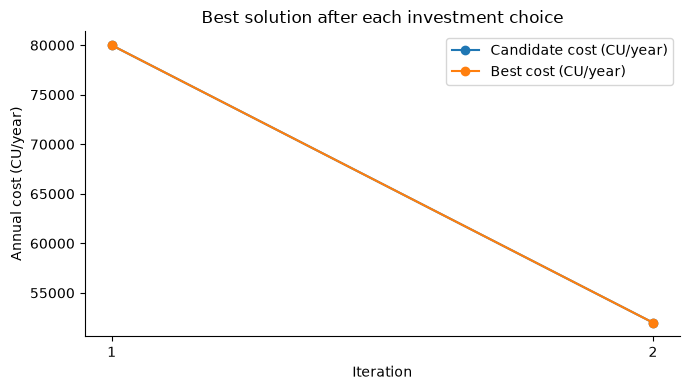

In [3]:
candidates = tuple(
    ou.BilevelIntegerAssignment.from_mapping(
        {
            "level_selected[MP_100]": 1,
            "gas_turbine_selected[GT]": selected,
            "hot_oil_selected[MP_100]": 0,
            "hot_oil_furnace_selected": 0,
        }
    )
    for selected in (0, 1)
)
scenario = ou.UtilitySystemScenario(
    case_study="tutorial", scenario="binary menu", data=data
)
run = ou.run_utility_system_binary_selection_decomposition(
    scenario,
    solve_master=ou.utility_system_binary_selection_candidate_solver(candidates),
    solve_subproblem=solve,
    max_iterations=len(candidates),
)
history = pd.DataFrame(
    [
        {
            "Iteration": iteration.iteration_index,
            "Candidate cost (CU/year)": iteration.subproblem.objective_value,
            "Best cost (CU/year)": iteration.solution_pool.best_objective_value,
        }
        for iteration in run.iterations
    ]
).set_index("Iteration")
assert len(run.iterations) == 2
assert len({iteration.assignment for iteration in run.iterations}) == 2
assert math.isclose(history.iloc[0]["Candidate cost (CU/year)"], 80000.0, abs_tol=1e-6)
assert math.isclose(
    run.solution_pool.best_objective_value, reference_cost, abs_tol=1e-6
)
assert math.isclose(reference_cost, 52000.0, abs_tol=1e-6)
display(history)
print("Stop reason:", run.stop_reason)
print("Bound-based convergence:", run.converged)
ax = history.plot(marker="o")
ax.set(
    ylabel="Annual cost (CU/year)",
    title="Best solution after each investment choice",
    xticks=history.index,
)
plt.tight_layout()
plt.show()

## What this demonstrates

The best objective drops from 80,000 to 52,000 CU/year. Both feasible investment choices were evaluated and the result matches the monolithic MILP. The iteration limit itself is **not** a proof of optimality: a larger candidate menu could omit the best design. This is an educational binary-selection decomposition using the bilevel APIs, not a thermodynamic nonlinear bilevel case study. For larger problems, inspect skipped-candidate diagnostics and use valid bounds before claiming gap convergence.